In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv('../telco_raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
print("Ukuran dataset:", df.shape)
df.head()

Ukuran dataset: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Info Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

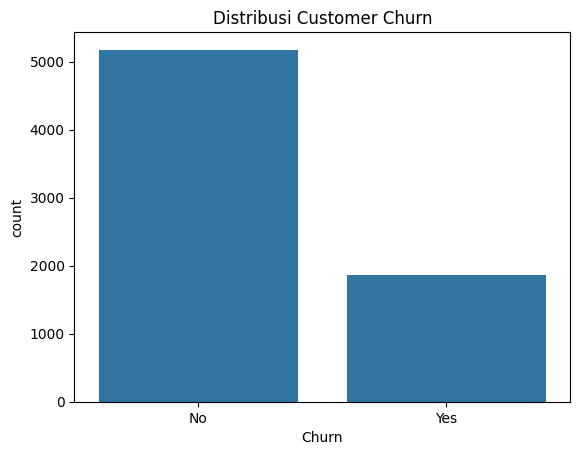

In [3]:
print("Info Dataset:")
df.info()

df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

print("\nMissing Values:")
print(df.isnull().sum())

sns.countplot(data=df, x='Churn')
plt.title('Distribusi Customer Churn')
plt.show()

In [4]:
df.dropna(inplace=True)
df.drop('customerID', axis=1, inplace=True)

X = df.drop('Churn', axis=1)
y = df['Churn']

le = LabelEncoder()
y = le.fit_transform(y)

X = pd.get_dummies(X, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Preprocessing Selesai!")
print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test:", X_test.shape)

Preprocessing Selesai!
Ukuran X_train: (5625, 30)
Ukuran X_test: (1407, 30)


In [5]:
X_train_df = pd.DataFrame(X_train, columns=X.columns)
X_test_df = pd.DataFrame(X_test, columns=X.columns)
y_train_df = pd.DataFrame(y_train, columns=['Churn'])
y_test_df = pd.DataFrame(y_test, columns=['Churn'])

X_train_df.to_csv('../preprocessing/telco_preprocessing/X_train.csv', index=False)
X_test_df.to_csv('../preprocessing/telco_preprocessing/X_test.csv', index=False)
y_train_df.to_csv('../preprocessing/telco_preprocessing/y_train.csv', index=False)
y_test_df.to_csv('../preprocessing/telco_preprocessing/y_test.csv', index=False)

print("Dataset bersih berhasil disimpan ke folder telco_preprocessing!")

Dataset bersih berhasil disimpan ke folder telco_preprocessing!
